In [1]:
# ============================================
# Phase 2 — Day 8: OpenCV Fundamentals
# Image Formation, Pixels, Color Spaces
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:" ,cv2.__version__)
print("NumPy Version :" ,np.__version__)
print("Ready for Phase 2!🚀" )

OpenCV Version: 4.13.0
NumPy Version : 2.4.6
Ready for Phase 2!🚀


In [3]:
# ============================================
# WHAT IS AN IMAGE IN PYTHON?
# ============================================

# An image is just a NumPy array!
# Black and white (grayscale) = 2D array (height x width)
# Color image = 3D array (height x width x 3 channels)

# Let's create a simple image from scratch
# 100x100 black image

black_image = np.zeros((100,100, 3), dtype = np.uint8)
print("Black image shape :", black_image.shape)
print("dtype:", black_image.dtype)
print("Min value:", black_image.min(), "Max values:", black_image.max())

# 100x100 white image
white_image = np.ones((100, 100, 3), dtype=np.uint8) * 255
print("\nWhite image shape:", white_image.shape)
print("Min value:", white_image.min(), "Max value:", white_image.max())

# What does shapes means ?
h,w ,c = black_image.shape 
print(f"\nHeight: {h}px , Width: {w}px, Channels: {c}")
print("Channels = 3 means BGR (Blue, Green , Red )- OpenCV's default color order ")

Black image shape : (100, 100, 3)
dtype: uint8
Min value: 0 Max values: 0

White image shape: (100, 100, 3)
Min value: 255 Max value: 255

Height: 100px , Width: 100px, Channels: 3
Channels = 3 means BGR (Blue, Green , Red )- OpenCV's default color order 


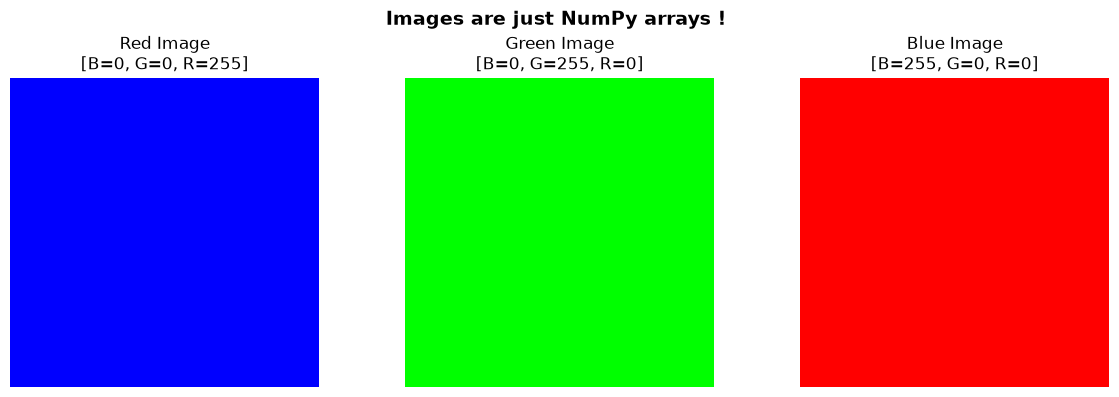

Each Image is a Numpy array of shape (100,100,3)
We set only one channel to 255 to get pure colors .


In [7]:
# ============================================
# CREATING COLORED IMAGES + VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# --- Pure Red Image ---
red_image = np.zeros((100,100, 3), dtype=np.uint8)
red_image[:, :, 2] = 255 
axes[0].imshow(red_image)
axes[0].set_title('Red Image\n[B=0, G=0, R=255]')
axes[0].axis('off')

# --- Pure Green Image ---
green_image = np.zeros((100, 100, 3), dtype=np.uint8)
green_image[:, :, 1] = 255  # channel 1 = Green in BGR
axes[1].imshow(green_image)
axes[1].set_title('Green Image\n[B=0, G=255, R=0]')
axes[1].axis('off')

# --- Pure Blue Image ---
blue_image = np.zeros((100, 100, 3), dtype=np.uint8)
blue_image[:, :, 0] = 255  # channel 0 = Blue in BGR
axes[2].imshow(blue_image)
axes[2].set_title('Blue Image\n[B=255, G=0, R=0]')
axes[2].axis('off')

plt.suptitle('Images are just NumPy arrays ! ', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

print("Each Image is a Numpy array of shape (100,100,3)")
print("We set only one channel to 255 to get pure colors .")

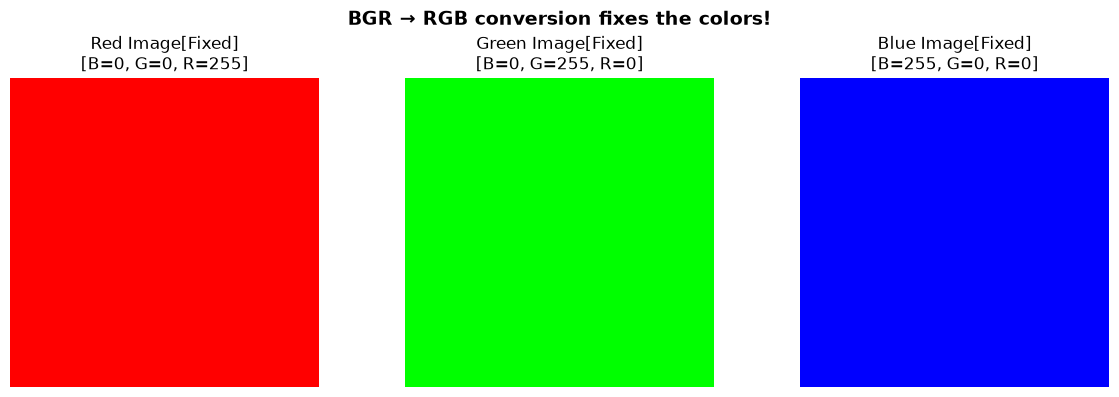

Rule: Always convert BGR→RGB before displaying with matplotlib
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [8]:
# ============================================
# FIX — Convert BGR to RGB for matplotlib
# ============================================

fig, axes = plt.subplots(1,3,figsize = (12, 4))

# --- Pure Red Image (Fixed) --- 
red_image = np.zeros((100,100 ,3) , dtype = np.uint8)
red_image[:, :, 2] = 255 
#Convert BGR to RGB before showing 
axes[0].imshow(cv2.cvtColor(red_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Red Image[Fixed]\n[B=0, G=0, R=255]')
axes[0].axis('off')

# --- Pure Green Image ---
green_image = np.zeros((100, 100, 3), dtype=np.uint8)
green_image[:, :, 1] = 255  # channel 1 = Green in BGR
#Convert BGR to RGB before showing
axes[1].imshow(cv2.cvtColor(green_image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Green Image[Fixed]\n[B=0, G=255, R=0]')
axes[1].axis('off')

# --- Pure Blue Image ---
blue_image = np.zeros((100, 100, 3), dtype=np.uint8)
blue_image[:, :, 0] = 255  # channel 0 = Blue in BGR
#Convert BGR to RGB before showing
axes[2].imshow(cv2.cvtColor(blue_image, cv2.COLOR_BGR2RGB))
axes[2].set_title('Blue Image[Fixed]\n[B=255, G=0, R=0]')
axes[2].axis('off')

plt.suptitle('BGR → RGB conversion fixes the colors!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Rule: Always convert BGR→RGB before displaying with matplotlib")
print("cv2.cvtColor(image, cv2.COLOR_BGR2RGB)")

Image saved!
Image Loaded!
Shape:  (300, 300, 3)
dtype: uint8


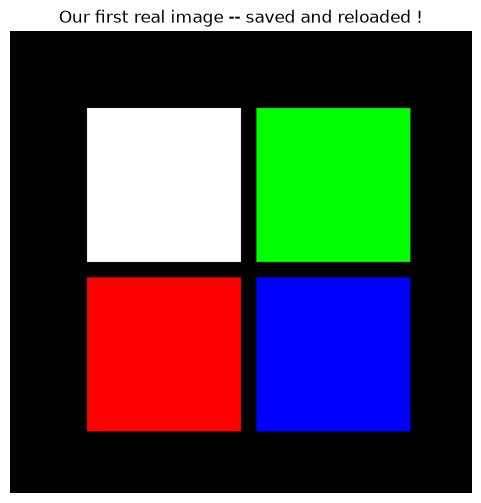

In [10]:
# ============================================
# CREATE, SAVE AND RELOAD A REAL IMAGE
# ============================================

# Create a simple test image with shapes
img = np.zeros((300,300, 3), dtype = np.uint8)

# Draw a white rectangle
img[50:150, 50:150] = [255, 255 , 255]  # white square

# Draw a red circle area (manually)
img[160:260, 50:150, 2]= 255            # red square (BGR: channel 2)

# Draw a green area
img[50:150, 160:260, 1] = 255           # green square (BGR: channel 1)

# Draw a blue area
img[160:260, 160:260, 0] = 255          # blue square (BGR: channel 0)


# Save the Image 
cv2.imwrite('/home/arpeetpadhy/test_image.png', img)
print("Image saved!")

# Reload it
loaded_img = cv2.imread('/home/arpeetpadhy/test_image.png')
print("Image Loaded!")
print("Shape: ", loaded_img.shape)
print("dtype:" , loaded_img.dtype)

# Display it 
plt.figure(figsize = (6,6))
plt.imshow(cv2.cvtColor(loaded_img, cv2.COLOR_BGR2RGB))
plt.title('Our first real image -- saved and reloaded !')
plt.axis('off')
plt.show()

Orignal shape: (300, 300, 3)
Grayscale:  (300, 300)

Original size:  (300, 300)
Resized small : (150, 150)
Resized large: (600, 600)

 Cropped shape: (100, 100, 3)


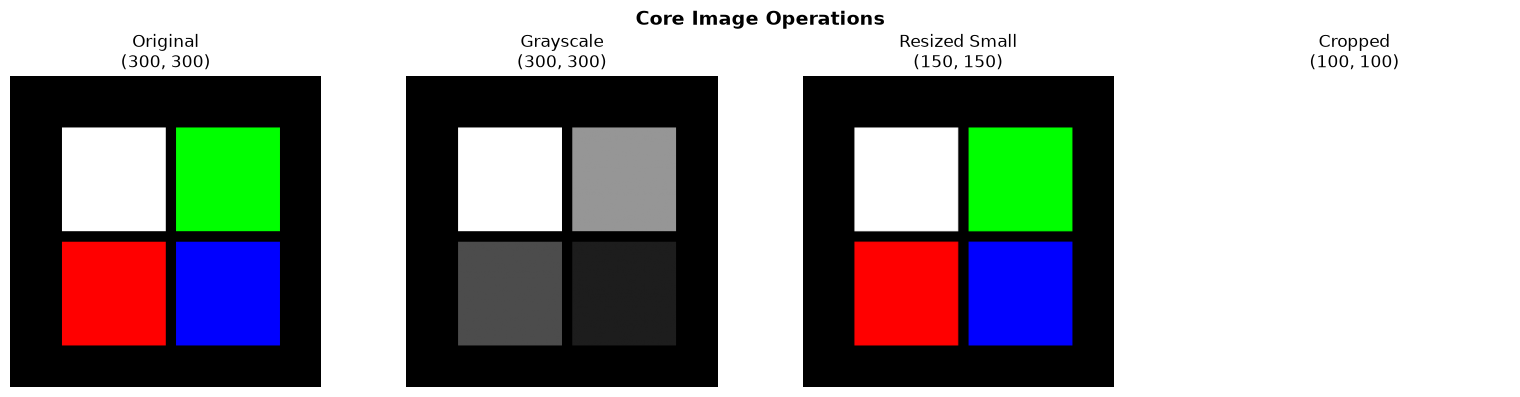

In [12]:
# ============================================
# CORE IMAGE OPERATIONS
# ============================================

# --- Grayscale conversion ---

gray = cv2.cvtColor(loaded_img, cv2.COLOR_BGR2GRAY)
print("Orignal shape:", loaded_img.shape)
print("Grayscale: ", gray.shape)     #notice : no  channel dimension! 

#--- Resize --- 
small = cv2.resize(loaded_img, (150,150))
large = cv2.resize(loaded_img, (600,600))
print("\nOriginal size: ", loaded_img.shape[:2])
print("Resized small :", small.shape[:2])
print("Resized large:", large.shape[:2])

# --- Crop ---
cropped = loaded_img[50:150, 50: 150]
print("\n Cropped shape:", cropped.shape)

# --- Display all ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(loaded_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Original\n{loaded_img.shape[:2]}')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title(f'Grayscale\n{gray.shape}')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Resized Small\n{small.shape[:2]}')
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[3].set_title(f'Cropped\n{cropped.shape[:2]}')
axes[3].axis('off')

plt.suptitle('Core Image Operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
